In [1]:
# INDIA_PROJECTED_CRS = "24378"

## Setup

In [2]:
# set libraries to refresh
%load_ext autoreload
%autoreload 2

In [16]:
from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd
gpd.options.io_engine = "pyogrio"

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import math
import matplotlib.cm

In [11]:
from gridsample.utils import create_ids, create_gmap_links, save_shapefiles
# from gridsample.mapping import create_interactive_map

In [12]:
import boto3

from s2cell.s2cell import lat_lon_to_cell_id
import s2sphere
from shapely.geometry import Polygon

from tqdm.notebook import tqdm

In [13]:
ROOT_DIR = Path("../")
DATA_DIR = ROOT_DIR / "data"
RAW_DATA_DIR = DATA_DIR / "01. Raw Data"
CLEANED_DATA_DIR = DATA_DIR / "02. Intermediate Outputs"
OUTPUT_DATA_DIR = DATA_DIR / "03. Final Outputs"
OUTPUT_DATA_DIR.mkdir(parents=True, exist_ok=True)

In [15]:
def generate_colormap(N):
    arr = np.arange(N)/N
    N_up = int(math.ceil(N/7)*7)
    arr.resize(N_up)
    arr = arr.reshape(7,N_up//7).T.reshape(-1)
    ret = matplotlib.cm.hsv(arr)
    n = ret[:,3].size
    a = n//2
    b = n-a
    
    # Create arrays of exactly matching sizes
    for i in range(3):
        ret[0:a,i] *= np.linspace(0.2, 1, a)
    ret[a:,3] *= np.linspace(1, 0.3, b)
    
    return ret[:N]  # Return only the requested number of colors

## 0. Load boundaries

In [8]:
boundaries_gdf = gpd.read_file(RAW_DATA_DIR / "01. MapSolve Boundaries/State_C_7/State_C_7.gpkg")
boundaries_gdf = boundaries_gdf.to_crs(4326)

<Axes: >

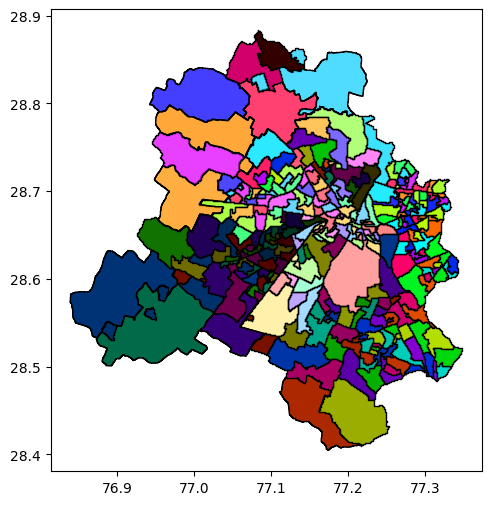

In [21]:
boundaries_gdf.plot(
    column="PCA_ID",
    figsize=(6, 6),
    cmap=ListedColormap(generate_colormap(len(boundaries_gdf))),
    edgecolor="black",
)
# create_interactive_map(boundaries_gdf, point_id_col="PCA_ID")

## 1. Download rooftops

### Functions

In [22]:
def get_s2_cell_ids_from_points(points, level=6) -> list[int]:
    """
    Get S2 cell IDs for the given points at the specified level.
    """
    s2_cell_id_list = points.geometry.apply(lambda geom: lat_lon_to_cell_id(geom.y, geom.x, level))
    s2_cell_ids_unique = s2_cell_id_list.unique().tolist()

    return s2_cell_ids_unique

In [23]:
def get_s2_cell_ids(gdf, level=6) -> list[int]:
    """
    Get S2 cell IDs of S2 cells that overlap the given GeoDataFrame at the specified level.
    """
    points = gdf.geometry.centroid.to_frame(name='geometry')
    s2_cell_ids = get_s2_cell_ids_from_points(points, level=level)

    return s2_cell_ids

In [24]:
def s2_cell_id_to_shape(s2_cell_id):
    """
    Convert an S2 cell ID to a shapely polygon.
    
    Parameters:
    - s2_cell_id (int): The S2 cell ID
    
    Returns:
    - shapely.geometry.Polygon: Polygon representing the S2 cell
    """
    # Convert string to int if necessary
    if isinstance(s2_cell_id, str):
        s2_cell_id = int(s2_cell_id)
    
    # Create an S2 cell from the ID
    cell = s2sphere.CellId(s2_cell_id)
    cell = s2sphere.Cell(cell)
    
    # Extract the vertices of the cell
    vertices = []
    for i in range(4):
        vertex = cell.get_vertex(i)
        lat_lng = s2sphere.LatLng.from_point(vertex)
        vertices.append((lat_lng.lng().degrees, lat_lng.lat().degrees))
    
    # Close the polygon by repeating the first vertex
    vertices.append(vertices[0])
    
    # Create a shapely polygon
    return Polygon(vertices)

def s2_cell_ids_to_shapes_gdf(s2_cell_ids):
    """
    Convert a list of S2 cell IDs to a GeoDataFrame with polygon geometries.
    
    Parameters:
    - s2_cell_ids (list): List of S2 cell IDs
    
    Returns:
    - geopandas.GeoDataFrame: GeoDataFrame with S2 cells as polygons
    """
    geometries = []
    for s2_id in s2_cell_ids:
        polygon = s2_cell_id_to_shape(s2_id)
        geometries.append(polygon)
    
    return gpd.GeoDataFrame(
        {'s2_cell_id': s2_cell_ids, 'geometry': geometries},
        crs="EPSG:4326"
    )

In [25]:
def download_VIDA_rooftops_data_by_s2_single(s2_cell_id: int, country_iso_code: str, target_data_dir: Path) -> None:
    """
    Download S2 rooftops data for a given S2 cell ID from the VIDA S3 bucket. URL:
    https://beta.source.coop/vida/google-microsoft-open-buildings/geoparquet/by_country_s2/country_iso=IND/
    """

    s2_rooftops_path = target_data_dir / f"{s2_cell_id}.parquet"

    if s2_rooftops_path.exists():
        print(f"File {s2_cell_id} already exists.")
    else:
        print(f"Downloading file for S2 cell ID: {s2_cell_id}")
        s2_rooftops_path.parent.mkdir(parents=True, exist_ok=True)
        s3 = boto3.client("s3", endpoint_url="https://data.source.coop")
        try:
            s3.download_file(
                "vida",
                f"google-microsoft-open-buildings/geoparquet/by_country_s2/country_iso={country_iso_code}/{s2_cell_id}.parquet",
                str(s2_rooftops_path),
            )
            print(f"File {s2_cell_id} downloaded.")
        except Exception as e:
            raise RuntimeError(f"Failed to download file for S2 cell ID {s2_cell_id}: {e}")

def download_VIDA_rooftops_data_by_s2(
    s2_cell_ids: list[int], country_iso_code: str, target_data_dir: Path
) -> None:
    """
    Download S2 rooftops data for multiple S2 cell IDs

    Parameters:
    - s2_cell_ids: list of S2 cell IDs
    - country_iso_code: ISO code of the country (e.g., "IND" for India)
    - target_data_dir: directory to save the downloaded data
    """

    for s2_cell_id in tqdm(s2_cell_ids, desc="Downloading rooftops by S2 cell"):
        download_VIDA_rooftops_data_by_s2_single(s2_cell_id, country_iso_code, target_data_dir)

### Run

#### Identify S2 cell IDs

In [26]:
s2_cell_ids = get_s2_cell_ids(boundaries_gdf)
s2_cell_ids

/var/folders/99/cwxq7sdx5d94rqxj57_crqbc0000gn/T/ipykernel_35961/3522774555.py:5: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  points = gdf.geometry.centroid.to_frame(name='geometry')


[4110942034859130880]

#### Check if identified cells cover all areas of interest

In [27]:
s2_cells_gdf = s2_cell_ids_to_shapes_gdf(s2_cell_ids)

In [28]:
# Does the S2 cell cover the entire area of the boundaries?
uncovered_area = boundaries_gdf.unary_union.difference(s2_cells_gdf.unary_union).area
print(f"{uncovered_area} square degrees area not covered by an S2 cell")

0.0 square degrees area not covered by an S2 cell


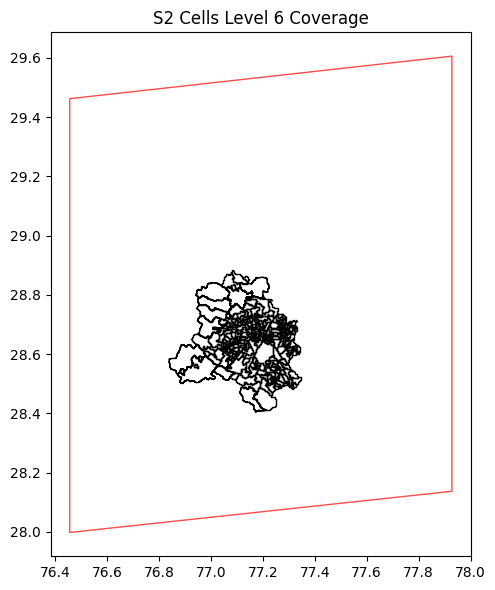

In [29]:
# Plot the S2 cells and the boundary
fig, ax = plt.subplots(1, 1, figsize=(6, 6))
boundaries_gdf.boundary.plot(ax=ax, color="black", linewidth=1)
s2_cells_gdf.plot(ax=ax, facecolor="none", edgecolor="red", alpha=0.7)
plt.title("S2 Cells Level 6 Coverage")
plt.tight_layout()
plt.show()

#### Download the S2 cells

In [30]:
download_VIDA_rooftops_data_by_s2(s2_cell_ids, "IND", RAW_DATA_DIR / "02. Rooftop Data")

File 4110942034859130880 already exists.


## 2. Load rooftops and match to areas

In [31]:
def get_matched_rooftop_centroids_from_s2_file(
    s2_cell_id: int, boundaries_gdf: gpd.GeoDataFrame
) -> gpd.GeoDataFrame:
    """
    Get rooftops from the S2 cell file that match the boundaries:
    1. loads the rooftops data for the specified S2 cell ID
    2. filters the rooftops to only those that intersect with the boundaries
    3. returns a GeoDataFrame of the matched rooftops centroids with unique IDs

    Parameters:
    - s2_cell_id (int): The S2 cell ID to filter rooftops for.
    - boundaries_gdf (gpd.GeoDataFrame): The GeoDataFrame containing the boundaries.
    """

    # load the rooftops data for the S2 cell
    s2_rooftops_path = RAW_DATA_DIR / "02. Rooftop Data" / f"{s2_cell_id}.parquet"
    s2_rooftops_gdf = gpd.read_parquet(s2_rooftops_path)

    # replace polygons with just the centroid of the rooftops
    s2_rooftop_centroids_gdf = s2_rooftops_gdf.set_geometry(
        s2_rooftops_gdf.geometry.centroid
    )

    # filter the boundaries dataset to only the shapes that overlap the S2 cell
    s2_cell_polygon = s2_cell_id_to_shape(s2_cell_id)
    boundaries_gdf_s2_overlap = boundaries_gdf[
        boundaries_gdf.intersects(s2_cell_polygon)
    ]

    # perform a spatial join to get the rooftops that intersect with the boundaries
    matched_rooftop_centroids_gdf = gpd.sjoin(
        s2_rooftop_centroids_gdf,
        boundaries_gdf_s2_overlap,
        how="inner",
        predicate="within",
    ).drop(columns=["index_right"])

    # add IDs to each rooftop
    matched_rooftop_centroids_gdf["s2_rooftop_id"] = create_ids(
        len(matched_rooftop_centroids_gdf), f"S2_{s2_cell_id}_ROOFTOP_"
    )

    return matched_rooftop_centroids_gdf

In [32]:
matched_rooftop_centroids_gdf_list = []
for s2_cell_id in tqdm(s2_cell_ids):
    matched_rooftop_centroids_gdf = get_matched_rooftop_centroids_from_s2_file(
        s2_cell_id, boundaries_gdf
    )
    matched_rooftop_centroids_gdf_list.append(matched_rooftop_centroids_gdf)

  0%|          | 0/1 [00:00<?, ?it/s]

/var/folders/99/cwxq7sdx5d94rqxj57_crqbc0000gn/T/ipykernel_35961/2961975021.py:21: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  s2_rooftops_gdf.geometry.centroid


In [33]:
matched_rooftop_centroids_gdf = pd.concat(matched_rooftop_centroids_gdf_list, ignore_index=True)

<Axes: >

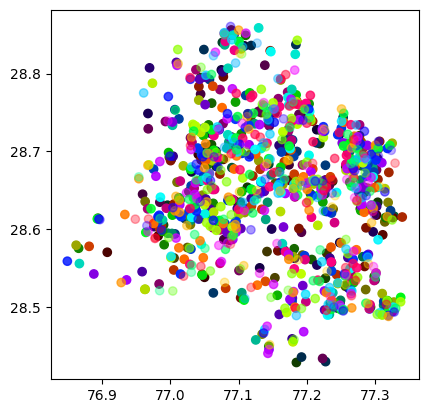

In [41]:
matched_rooftop_centroids_gdf.sample(1000).plot(
    cmap=ListedColormap(generate_colormap(len(matched_rooftop_centroids_gdf))),
)

### Save to file

In [35]:
save_shapefiles(
    matched_rooftop_centroids_gdf,
    CLEANED_DATA_DIR / "01. Matched Rooftop Data",
    "matched_rooftops_delhi_test",
    ["csv", "kml", "parquet"],
)

/Users/amiremami/.pyenv/versions/3.12.9/envs/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Lossy conversion occurred when trying to set 64 bit integer field from a real value.
  ogr_write(
/Users/amiremami/.pyenv/versions/3.12.9/envs/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value 'IND' of field matched_rooftops_delhi_test.area_in_meters parsed incompletely to real 0.
  ogr_write(
/Users/amiremami/.pyenv/versions/3.12.9/envs/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value 'Delhi' of field matched_rooftops_delhi_test.SubDist_N parsed incompletely to real 0.
  ogr_write(
/Users/amiremami/.pyenv/versions/3.12.9/envs/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value 'Delhi Cantonment (CB)' of field matched_rooftops_delhi_test.SubDist_N parsed incompletely to real 0.
  ogr_write(
/Users/amiremami/.pyenv/versions/3.12.9/envs/geospatial/lib/python3.12/site-packages

## 3. Sample rooftops

In [42]:
NUM_ROOFTOPS_PER_AREA = 10

In [43]:
sampled_rooftops = matched_rooftop_centroids_gdf.groupby("PCA_ID", group_keys=False).apply(
    lambda x: x.sample(n=min(NUM_ROOFTOPS_PER_AREA, x.shape[0]), random_state=42)
)

In [44]:
# First, create a helper column to track the sequence within each group
sampled_rooftops = sampled_rooftops.sort_values('PCA_ID')
sampled_rooftops['rooftop_number'] = sampled_rooftops.groupby('PCA_ID').cumcount() + 1

# Then use this column to create your ID
sampled_rooftops["sample_rooftop_id"] = sampled_rooftops.apply(
    lambda row: f"PCA_ID_{row['PCA_ID']}_ROOFTOP_{row['rooftop_number']}", axis=1
)

# Optionally drop the helper column if not needed
sampled_rooftops = sampled_rooftops.drop(columns=['rooftop_number'])

In [45]:
print(len(sampled_rooftops))

2810


<Axes: >

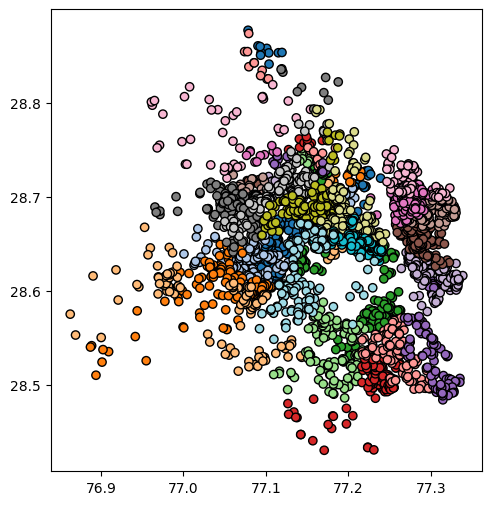

In [52]:
sampled_rooftops.plot(column="PCA_ID", figsize=(6, 6), cmap="tab20", edgecolor="black")

### Add gmap link and select columns

In [47]:
sampled_rooftops["latitude"] = sampled_rooftops.geometry.y
sampled_rooftops["longitude"] = sampled_rooftops.geometry.x
sampled_rooftops["gmap_link"] = create_gmap_links(
    df=sampled_rooftops,
    lat_name="latitude",
    lon_name="longitude",
)

In [48]:
sampled_rooftops = sampled_rooftops[
    [
        "sample_rooftop_id",
        "latitude",
        "longitude",
        "gmap_link",
        "s2_rooftop_id",
        "s2_id",
        "UID",
        "PCA_ID",
        "State_C",
        "State_N",
        "Ward_C",
        "Dist_C",
        "Dist_N",
        "SubDist_C",
        "SubDist_N",
        "TV_C",
        "TV_N",
        "TOT_P",
        "geometry",
    ]
]

### Save sampled data

In [49]:
sampled_rooftops.head()

,sample_rooftop_id,latitude,longitude,gmap_link,s2_rooftop_id,s2_id,UID,PCA_ID,State_C,State_N,Ward_C,Dist_C,Dist_N,SubDist_C,SubDist_N,TV_C,TV_N,TOT_P,geometry
2453433,PCA_ID_800441-1_ROOFTOP_1,28.858014,77.100978,https://www.google.com/maps/search/?api=1&quer...,S2_4110942034859130880_ROOFTOP_2453434,4110942034859130880,5.0,800441-1,7.0,Delhi,1.0,NaN,None,NaN,NaN,800441.0,Delhi,55512,POINT (77.10098 28.85801)
2455995,PCA_ID_800441-1_ROOFTOP_2,28.853243,77.103457,https://www.google.com/maps/search/?api=1&quer...,S2_4110942034859130880_ROOFTOP_2455996,4110942034859130880,5.0,800441-1,7.0,Delhi,1.0,NaN,None,NaN,NaN,800441.0,Delhi,55512,POINT (77.10346 28.85324)
2450271,PCA_ID_800441-1_ROOFTOP_3,28.853389,77.094087,https://www.google.com/maps/search/?api=1&quer...,S2_4110942034859130880_ROOFTOP_2450272,4110942034859130880,5.0,800441-1,7.0,Delhi,1.0,NaN,None,NaN,NaN,800441.0,Delhi,55512,POINT (77.09409 28.85339)
2457899,PCA_ID_800441-1_ROOFTOP_4,28.853368,77.115039,https://www.google.com/maps/search/?api=1&quer...,S2_4110942034859130880_ROOFTOP_2457900,4110942034859130880,5.0,800441-1,7.0,Delhi,1.0,NaN,None,NaN,NaN,800441.0,Delhi,55512,POINT (77.11504 28.85337)
2447630,PCA_ID_800441-1_ROOFTOP_5,28.860679,77.090328,https://www.google.com/maps/search/?api=1&quer...,S2_4110942034859130880_ROOFTOP_2447631,4110942034859130880,5.0,800441-1,7.0,Delhi,1.0,NaN,None,NaN,NaN,800441.0,Delhi,55512,POINT (77.09033 28.86068)


In [50]:
save_shapefiles(
    sampled_rooftops,
    OUTPUT_DATA_DIR / "01. Sampled Rooftop Data",
    "sampled_rooftops_delhi_test",
    ["csv", "parquet", "kml"],
)

/Users/amiremami/.pyenv/versions/3.12.9/envs/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value 'https://www.google.com/maps/search/?api=1&query=28.85801392381695,77.10097788685498' of field sampled_rooftops_delhi_test.latitude parsed incompletely to real 0.
  ogr_write(
/Users/amiremami/.pyenv/versions/3.12.9/envs/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value 'S2_4110942034859130880_ROOFTOP_2453434' of field sampled_rooftops_delhi_test.longitude parsed incompletely to real 0.
  ogr_write(
/Users/amiremami/.pyenv/versions/3.12.9/envs/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value 'Delhi' of field sampled_rooftops_delhi_test.SubDist_N parsed incompletely to real 0.
  ogr_write(
/Users/amiremami/.pyenv/versions/3.12.9/envs/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value 'https://www.google.com/maps/search/?api=1&query=28.853242682630245,77.10345653050864

## Scraps

In [ ]:
# def create_grid_points(gdf, cell_size=0.05) -> gpd.GeoDataFrame:
#     """
#     Create a grid of points within the bounds of the unary geometry of the GeoDataFrame.

#     Parameters:
#     - gdf: GeoDataFrame
#     - cell_size: float, size of the grid cells

#     Returns:
#     - GeoDataFrame with grid points
#     """

#     bounds = gdf.unary_union.bounds
#     min_lon, min_lat, max_lon, max_lat = bounds

#     # Create a grid of points
#     lons = np.arange(min_lon, max_lon, cell_size)
#     lats = np.arange(min_lat, max_lat, cell_size)
#     lon_grid, lat_grid = np.meshgrid(lons, lats)

#     # Flatten the grid and create a GeoDataFrame
#     points = gpd.GeoDataFrame(
#         geometry=gpd.points_from_xy(lon_grid.flatten(), lat_grid.flatten()),
#         crs="EPSG:4326",
#     )

#     # Filter points that are within the unary geometry
#     points = points[points.geometry.within(gdf.unary_union)]

#     return points

In [ ]:
# import os
# import concurrent.futures
# from concurrent.futures import ThreadPoolExecutor

# def download_VIDA_rooftops_data_by_s2(
#     s2_cell_ids: list[int], country_iso_code: str, target_data_dir: Path, n_jobs: int = -1
# ) -> None:
#     """
#     Download S2 rooftops data for multiple S2 cell IDs in parallel.

#     Args:
#         s2_cell_ids: List of S2 cell IDs to download data for
#         country_iso_code: ISO code for the country (e.g. "IND", "PHL")
#         target_data_dir: Directory to save downloaded files
#         n_jobs: Number of concurrent downloads. If -1, uses all available cores.
#     """

#     if not isinstance(n_jobs, int) or n_jobs < -1 or n_jobs == 0:
#         raise ValueError("n_jobs must be -1 or a positive integer.")

#     if n_jobs == -1:
#         n_jobs = os.cpu_count() or 1  # 1 in case os.cpu_count() returns None

#     print(f"Downloading rooftops data for {len(s2_cell_ids)} S2 cell IDs in parallel using {n_jobs} jobs.")
    
#     # Track errors
#     error_count = 0
#     errors = {}
    
#     # Define a wrapper function to handle exceptions
#     def download_with_error_handling(s2_cell_id, country_iso_code, target_data_dir):
#         try:
#             download_VIDA_rooftops_data_by_s2_single(s2_cell_id, country_iso_code, target_data_dir)
#             return s2_cell_id, None
#         except Exception as e:
#             return s2_cell_id, str(e)
    
#     # Use ThreadPoolExecutor for I/O bound operations
#     with ThreadPoolExecutor(max_workers=n_jobs) as executor:
#         futures = [
#             executor.submit(
#                 download_with_error_handling, s2_cell_id, country_iso_code, target_data_dir
#             )
#             for s2_cell_id in s2_cell_ids
#         ]
        
#         # Show progress with tqdm
#         progress_bar = tqdm(
#             total=len(futures),
#             desc="Downloading rooftops data"
#         )
        
#         for future in concurrent.futures.as_completed(futures):
#             s2_cell_id, error = future.result()
            
#             if error:
#                 error_count += 1
#                 errors[s2_cell_id] = error
#                 progress_bar.set_description(f"Downloading rooftops data (errors: {error_count})")
                
#             progress_bar.update(1)
        
#         progress_bar.close()
    
#     # Print summary of errors
#     if errors:
#         print(f"\n⚠️ {error_count} errors occurred during download:")
#         for s2_cell_id, error in errors.items():
#             print(f"  - S2 cell {s2_cell_id}: {error}")
#         print(f"{len(s2_cell_ids) - error_count} of {len(s2_cell_ids)} files downloaded successfully.")
#     else:
#         print(f"\n✅ All {len(s2_cell_ids)} files downloaded successfully.")